In [57]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [58]:
df = pd.read_csv("data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [59]:
df.shape

(1000, 8)

In [60]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [63]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [64]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [65]:
#finding Categories in each columns
print("Categories in 'gender' varible:     ",end="")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' varible:    ",end="")
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' variable: ", end="")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' varible:  ",end="")
print(df['lunch'].unique())

print("Categories in test_preparation_course' varible: ",end="")
print(df['test_preparation_course'].unique())

Categories in 'gender' varible:     <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' varible:    <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental_level_of_education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' varible:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test_preparation_course' varible: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [66]:
#Defining numerical and categorical features
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object','category']).columns

#Printing Columns
print('We have {} Numerical Features : {}' .format(len(numerical_features),numerical_features))
print('We have {} Categorical Features : {}' .format(len(categorical_features),categorical_features))


We have 3 Numerical Features : Index(['math_score', 'reading_score', 'writing_score'], dtype='str')
We have 5 Categorical Features : Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')


In [67]:
df['total_score'] = df ['math_score'] + df['reading_score'] + df['writing_score']
df['average_score']= df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [68]:
#Checking how many students got full marks in each subject
reading_full = df[df['reading_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()
math_full = df[df['math_score'] == 100]['average_score'].count()

print(f'Number of students with full marks in reading: {reading_full}')
print(f'Number of students with full marks in writing: {writing_full}')     
print(f'Number of students with full marks in math: {math_full}')

Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
Number of students with full marks in math: 7


In [69]:
#Finding how many students got less than 20 marks in each subject
reading_less_20 =df[df['reading_score'] < 20]['average_score'].count()
writing_less_20 = df[df['writing_score'] < 20]['average_score'].count()
math_less_20 = df[df['math_score'] < 20]['average_score'].count()

print(f'Numbers of students with less than 20 marks in reading are: {reading_less_20}')
print(f'Numbers of students with less than 20 marks in writing are: {writing_less_20}')
print(f'Numbers of students with less than 20 marks in math are: {math_less_20}')   

Numbers of students with less than 20 marks in reading are: 1
Numbers of students with less than 20 marks in writing are: 3
Numbers of students with less than 20 marks in math are: 4


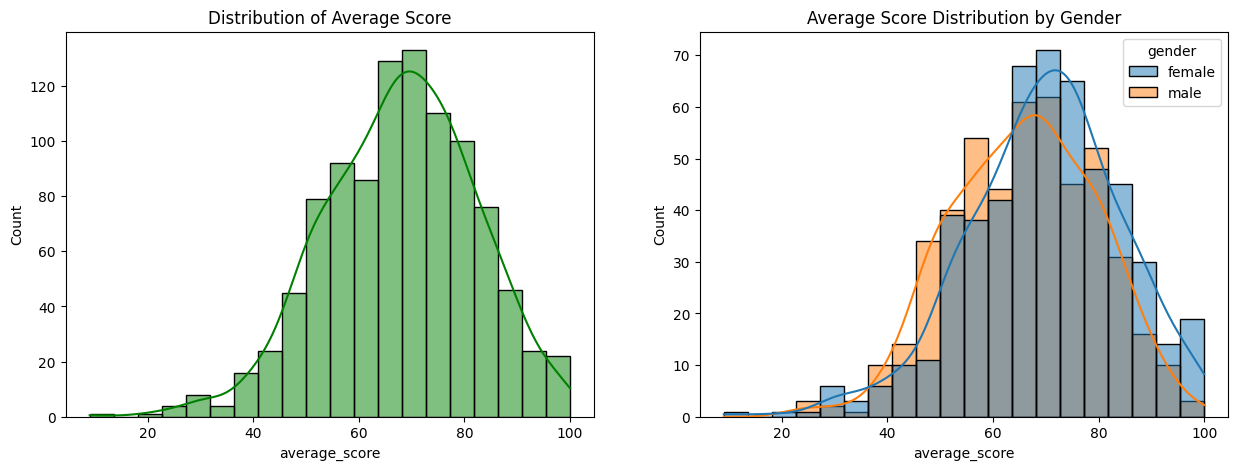

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(15,5))

sns.histplot(data=df, x='average_score', bins=20, kde=True, color='g', ax=axs[0])
axs[0].set_title('Distribution of Average Score')

sns.histplot(data=df, x='average_score', bins=20, kde=True, hue='gender', ax=axs[1])
axs[1].set_title('Average Score Distribution by Gender')
plt.savefig("average_score_distribution.png", dpi=1080)
plt.show()

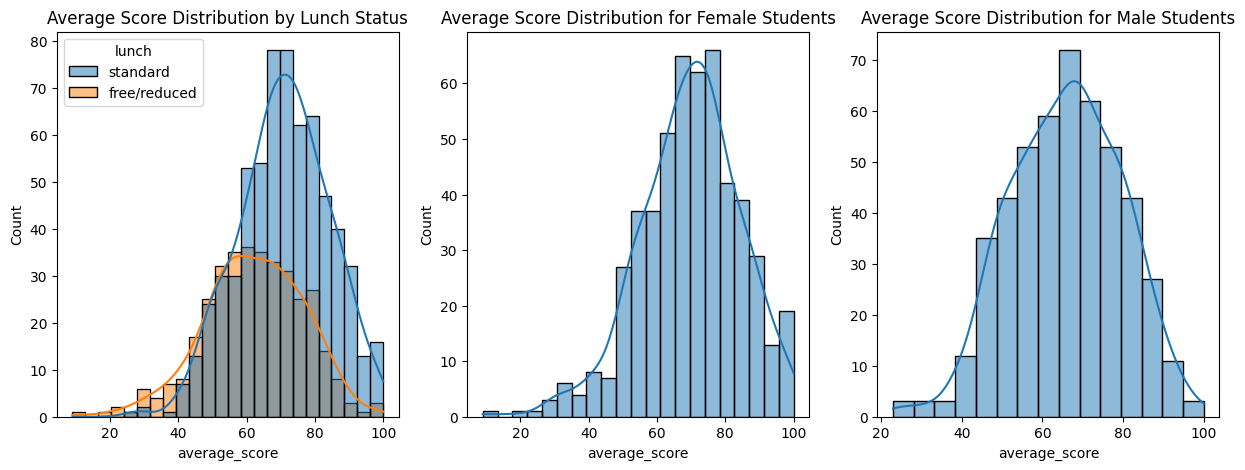

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15,5))

# Plot 1
sns.histplot(data=df, x='average_score',
             hue='lunch',
             kde=True, ax=axs[0])
axs[0].set_title('Average Score Distribution by Lunch Status')

# Plot 2
sns.histplot(data=df[df.gender == 'female'],
             x='average_score', kde=True, ax=axs[1])
axs[1].set_title('Average Score Distribution for Female Students')

# Plot 3
sns.histplot(data=df[df.gender == 'male'],
             x='average_score', kde=True, ax=axs[2])
axs[2].set_title('Average Score Distribution for Male Students')

# Save the figure
plt.savefig("average_score_distribution.png", dpi=1080)

plt.show()

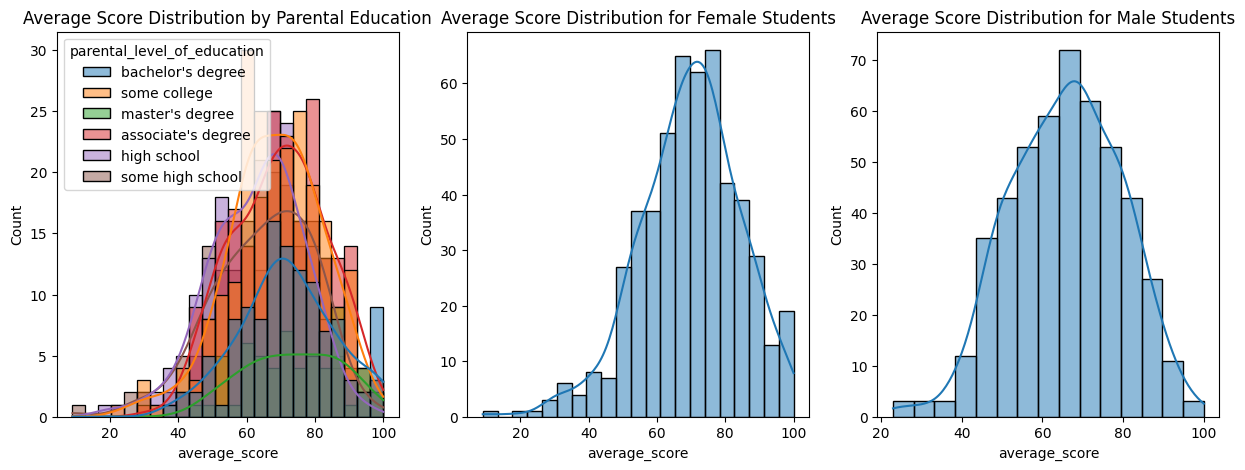

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15,5))

# Plot 1
sns.histplot(data=df, x='average_score',
             hue='parental_level_of_education',
             kde=True, ax=axs[0])
axs[0].set_title('Average Score Distribution by Parental Education')

# Plot 2
sns.histplot(data=df[df.gender == 'female'],
             x='average_score', kde=True, ax=axs[1])
axs[1].set_title('Average Score Distribution for Female Students')

# Plot 3
sns.histplot(data=df[df.gender == 'male'],
             x='average_score', kde=True, ax=axs[2])
axs[2].set_title('Average Score Distribution for Male Students')

# Save the figure
plt.savefig("average_score_distribution.png", dpi=1080)

plt.show()

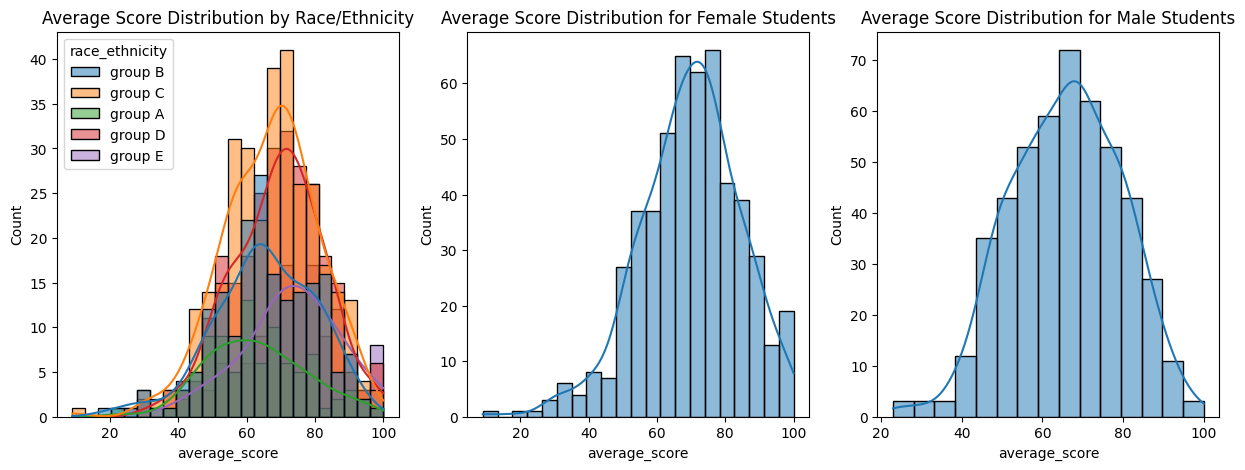

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15,5))

# Plot 1
sns.histplot(data=df, x='average_score',
             hue='race_ethnicity',
             kde=True, ax=axs[0])
axs[0].set_title('Average Score Distribution by Race/Ethnicity')

# Plot 2
sns.histplot(data=df[df.gender == 'female'],
             x='average_score', kde=True, ax=axs[1])
axs[1].set_title('Average Score Distribution for Female Students')

# Plot 3
sns.histplot(data=df[df.gender == 'male'],
             x='average_score', kde=True, ax=axs[2])
axs[2].set_title('Average Score Distribution for Male Students')

# Save the figure
plt.savefig("average_score_distribution by race.png", dpi=1080)

plt.show()

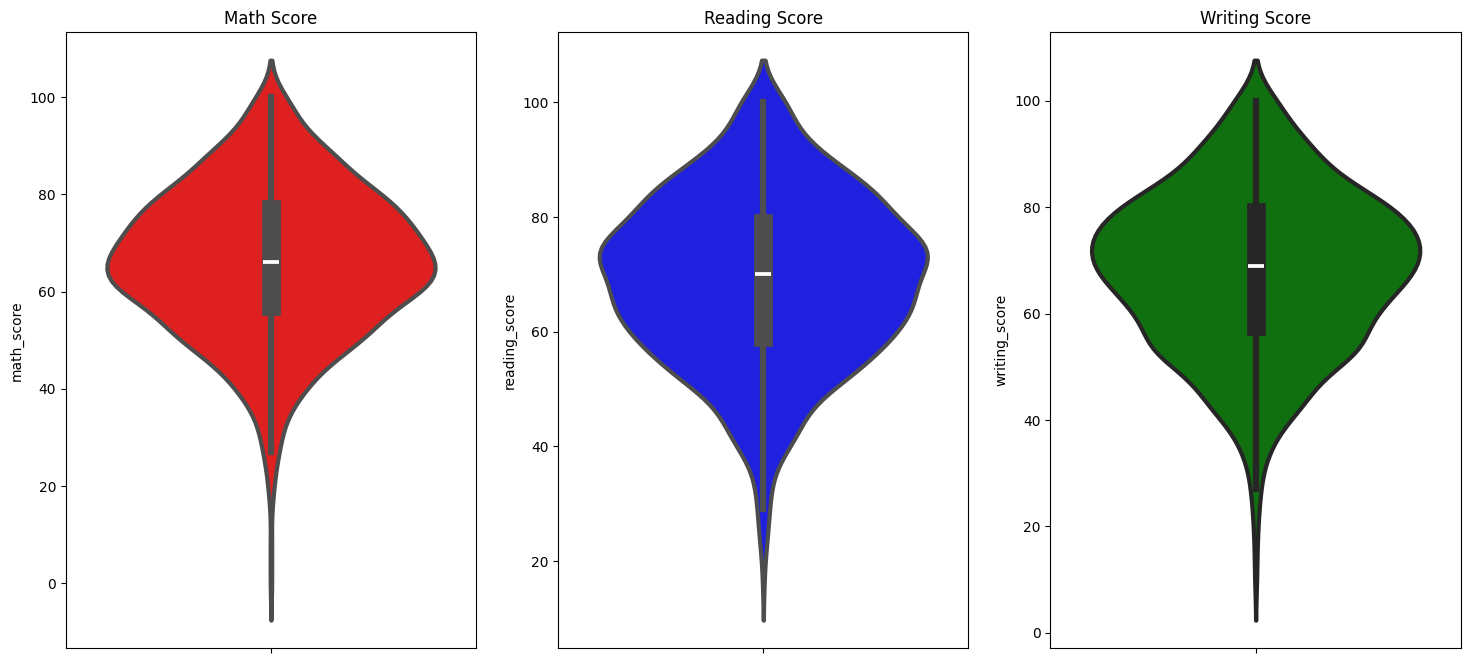

In [106]:
plt.figure(figsize=(18,8))

plt.subplot(1, 3, 1)
plt.title('Math Score')
sns.violinplot(y='math_score', data=df,color='red',linewidth=3)

plt.subplot(1,3,2)
plt.title('Reading Score')
sns.violinplot(y='reading_score', data=df,color='blue',linewidth=3)

plt.subplot(1,3,3)
plt.title('Writing Score')
sns.violinplot(y='writing_score', data=df,color='green',linewidth=3)

plt.savefig("distribution by score using violin plots.png", dpi=1080)
plt.show()

In [101]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
